# Agentic Architecture 5: Multi-Agent Systems

In this notebook, we advance to one of the most powerful and flexible architectures: the **Multi-Agent System**. This pattern moves beyond the concept of a single agent, no matter how complex, and instead models a team of specialized agents that collaborate to solve a problem. Each agent has a distinct role, persona, and set of skills, mirroring how human expert teams work.

This approach allows for a profound 'division of labor', where complex problems are broken down into sub-tasks and assigned to the agent best suited for the job. To showcase its power, we will conduct a direct comparison. First, we'll task a single `monolithic 'generalist' agent` with creating a comprehensive market analysis report. Then, we will assemble a `specialist team` — a Technical Analyst, a News Analyst, and a Financial Analyst—and have a fourth 'Manager' agent synthesize their expert inputs into a final report. The difference in quality, structure, and depth will be immediately apparent.

### Definition

A `Multi-Agent System` is an architecture where a group of distinct, specialized agents collaborate (or sometimes compete) to achieve a common goal. A central controller or a defined workflow protocol is used to manage communication and route tasks between the agents.

### High-level Workflow

1. **Decomposition:** A main controller or the user provides a complex task.
2. **Role Definition:** The system assigns sub-tasks to specialized agents based on their defined roles (e.g., 'Researcher', 'Coder', 'Critic', 'Writer').
3. **Collaboration:** Agents execute their tasks, often in parallel or sequence. They pass their outputs to each other or to a central 'blackboard'.
4. **Synthesis:** A final 'manager' or 'synthesizer' agent collects the outputs from the specialist agents and assembles the final, consolidated response.

### When to Use / Applications

- **Complex Report Generation:** Creating detailed reports that require expertise from multiple domains (e.g., financial analysis, scientific research).
- **Software Development Pipelines:** Simulating a dev team with a programmer, a code reviewer, a tester, and a project manager.
- **Creative Brainstorming:** A team of agents with different 'personalities' (e.g., one optimistic, one cautious, one wildly creative) can generate a more diverse set of ideas.

### Strengths & Weaknesses

- **Strengths:**
    - **Specialization & Depth:** Each agent can be fine-tuned with a specific persona and tools, leading to higher-quality work in its domain.
    - **Modularity & Scalability:** It's easy to add, remove, or upgrade individual agents without redesigning the entire system.
    - **Parallelism:** Multiple agents can work on their sub-tasks simultaneously, potentially reducing overall task time
- **Weaknesses:**
    - **Coordination Overhead:** Managing the communication and workflow between agents adds complexity to the system design.
    - **Increased Cost & Latency:** Running multiple agents involves more LLM calls, which can be more expensive and slower than a single-agent approach.


## Phase 0: Foundation & Setup

We'll begin with our standard setup process: installing libraries and configuring API keys for OpenRouter, LangSmith, and our Tavily web search tool.

In [ ]:
import os
import re
import json
from typing import Annotated, TypedDict, Optional
from dotenv import load_dotenv

# Pydantic for data modeling / validation
from pydantic import BaseModel, Field

# LangChain components
from langchain_openrouter import ChatOpenRouter                    # OpenRouter LLM wrapper
from langchain_tavily import TavilySearch                          # Tavily search tool wrapper 
from langchain_core.messages import SystemMessage, HumanMessage    # Base class for messages in LangChain
from langchain_core.messages import ToolMessage, AIMessage         # For tool calls and AI responses
from langchain_core.prompts import ChatPromptTemplate              # For creating chat prompts

# LangGraph components
from langgraph.graph import StateGraph, START, END                        # Build a state machine graph
from langgraph.types import Send                                   # For sending messages between nodes
from langgraph.graph.message import AnyMessage, add_messages       # For handling messages in the graph
from langgraph.prebuilt import ToolNode, tools_condition           # Prebuilt nodes and conditions

# For pretty printing 
from rich.console import Console  
from rich.markdown import Markdown     


# --- API Key and Tracing Setup ---
load_dotenv()  

# Enable LangSmith tracing for monitoring and debugging
os.environ["LANGSMITH_PROJECT"] = "Agentic Architecture - Multi-Agent (OpenRouter)"

# Verify that all required API keys are available
for key in ["OPENROUTER_API_KEY", "LANGSMITH_API_KEY", "TAVILY_API_KEY"]:
    if not os.environ.get(key):
        print(f"{key} not found. Please create a .env file and set it.")

print("Environment variables loaded and everything is set up.")

Environment variables loaded and everything is set up.


## Phase 1: The Baseline - A Monolithic 'Generalist' Agent

To showcase the value of a specialist team, we first need to see how a single agent performs on a complex task. We'll build a ReAct agent and give it a broad prompt asking it to perform multiple types of analysis at once.

### Step 1.1: Building the Monolithic Agent

We will construct a standard ReAct agent. We'll provide it with a web search tool and a very general system prompt that asks it to be a comprehensive financial analyst.

In [7]:
console = Console()

# Define the tool and the llm
search_tool = TavilySearch(max_results=3, name="web_search")

llm = ChatOpenRouter(
    model="openrouter/free",
    temperature=0
)
llm_with_tools = llm.bind_tools([search_tool])

In [8]:
# Define the shared state for both agents
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

# Define the monolithic agent node
def monolithic_agent_node(state: AgentState):
    console.print("--- MONOLITHIC AGENT: Thinking... ---")

    response = llm_with_tools.invoke(state["messages"])
    return {
        "messages": [response]
    }

tool_node = ToolNode([search_tool])

# Define a condition function that routes to the tool node if the tool is invoked, otherwise ends the graph
def tools_condition_with_end(state):
    result = tools_condition(state)

    if isinstance(result, str):
        return {
            result: "tools",
            "__default__": END
        }
    elif isinstance(result, dict):
        result["__default__"] = END
        return result
    else:
        raise TypeError(f"Unexpected return type from tools_condition: {type(result)}")

In [11]:
# Build the ReAct graph for the monolithic agent
mono_graph_builder = StateGraph(AgentState)

mono_graph_builder.add_node("agent", monolithic_agent_node)
mono_graph_builder.add_node("tools", tool_node)

mono_graph_builder.set_entry_point("agent")

mono_graph_builder.add_conditional_edges(
    "agent",
    tools_condition,
    {
        "tools": "tools",
        END: END
    }
)
mono_graph_builder.add_edge("tools", "agent")

monolithic_agent_app = mono_graph_builder.compile()

print("Monolithic 'generalist' agent graph compiled successfully.")

Monolithic 'generalist' agent graph compiled successfully.


### Step 1.2: Testing the Monolithic Agent

We'll give the generalist agent a complex task: create a full market analysis report for a company, covering three distinct areas.


In [12]:
company = "Google DeepMind"
monolithic_query = f"Create a brief but comprehensive market analysis report for {company}. The report should include three sections: 1. A summary of recent news and market sentiment. 2. A basic technical analysis of the stock's price trend. 3. A look at the company's recent financial performance."

console.print(f"[bold yellow]Testing MONOLITHIC agent on a multi-faceted task:[/bold yellow]\n'{monolithic_query}'\n")

final_mono_output = monolithic_agent_app.invoke({
    "messages": [
        SystemMessage(content="You are a single, expert financial analyst. You must create a comprehensive report covering all aspects of the user's request."),
        HumanMessage(content=monolithic_query)
    ]
})

console.print("\n--- [bold red]Final Report from Monolithic Agent[/bold red] ---")
console.print(Markdown(final_mono_output['messages'][-1].content))

Testing MONOLITHIC agent on a multi-faceted task:
'Create a brief but comprehensive market analysis report for Google DeepMind. The report should include three 
sections: 1. A summary of recent news and market sentiment. 2. A basic technical analysis of the stock's price 
trend. 3. A look at the company's recent financial performance.'

--- MONOLITHIC AGENT: Thinking... ---

--- MONOLITHIC AGENT: Thinking... ---

--- MONOLITHIC AGENT: Thinking... ---

--- Final Report from Monolithic Agent ---

1. Summary of Recent News and Market Sentiment                                                                     
Alphabet (GOOGL) has surged 160% year-to-date, briefly surpassing Nvidia in market cap following a $200 billion    
Anthropic cloud commitment. Market sentiment is overwhelmingly bullish, driven by AI investments (Gemini,          
DeepMind), cloud growth (63% YoY revenue increase), and strong enterprise demand for AI solutions. Analysts        
highlight Alphabet's diversified AI stack (search, YouTube, cloud infrastructure) as a competitive advantage.      
However, concerns persist about concentration risk from Anthropic's massive cloud spending, which could impact     
backlog sustainability. Post-earnings, JPMorgan labeled GOOGL their "top overall pick" in tech, citing "standout   
quarter" performance and accelerating cloud growth.                                                                

2. Technical Analysis of Stock Price Trend                                                                         
Alphabet stock (GOOGL) is up 32.6% YTD, trading near its 52-week high of $256.55 at $251.16. A "golden cross"      
pattern (50-day MA crossing above 200-day MA) signals a bullish breakout, reinforced by strong earnings momentum   
and technical support levels. Analysts project 11.23% upside (vs. 27% for META/AMZN), with technical indicators    
suggesting continued upward trajectory in the near term.                                                           

3. Recent Financial Performance                                                                                    
Q1 earnings exceeded expectations, fueled by 63% YoY growth in Google Cloud revenue. The cloud backlog doubled to  
$462 billion, indicating robust demand for AI-driven cloud services. Alphabet revised its 2026 capex forecast to   
$180–$190B (up from $175–$185B), reflecting sustained AI infrastructure investment. JPMorgan and Mizuho analysts   
raised price targets, citing underestimation of cloud revenue potential and strong operational execution.

**Discussion of the Output:** 

The monolithic agent produced a report. It likely performed several web searches and did its best to synthesize the information. However, the output may have some weaknesses:

- **Lack of Structure:** The sections might blend together, without clear headings or a professional format.
- **Superficial Analysis:** Trying to be an expert in three domains at once, the agent might provide only high-level summaries without much depth in any single area.
- **Generic Tone:** The language might be generic, lacking the specific jargon and focus of a true specialist in each field.

This result is our baseline. It's functional, but not exceptional. Now, we will build a specialist team to see if we can do better.

## Phase 2: The Advanced Approach - A Multi-Agent Specialist Team

Now we'll build our team: a News Analyst, a Technical Analyst, and a Financial Analyst. Each will be its own agent node with a specific persona. A final Report Writer will act as the manager, compiling their work.

### Step 2.1: Defining the Specialist Agent Nodes

We will create three distinct agent nodes. The key difference is the highly specific system prompt we give each one. This prompt defines their persona, their area of expertise, and the exact format their output should take. This is how we enforce specialization.


In [ ]:
# The state for our multi-agent system will hold the outputs of each specialist
class MultiAgentState(TypedDict):
    user_request: str
    news_report: Optional[str]
    technical_report: Optional[str]
    financial_report: Optional[str]
    final_report: Optional[str]

# Tool-execution loop
def run_agent_with_tools(llm_with_tools, tools_by_name: dict, messages: list) -> str:
    """
    ReAct loop with automatic argument coercion for common LLM mistakes.
    """
    while True:
        response = llm_with_tools.invoke(messages)
        messages.append(response)

        if not response.tool_calls:
            return response.content

        for tc in response.tool_calls:
            tool_fn = tools_by_name.get(tc["name"])
            if tool_fn is None:
                result = f"Error: tool '{tc['name']}' not found."
            else:
                clean_args = {}
                for k, v in tc["args"].items():
                    if isinstance(v, str):
                        stripped = v.strip()
                        if stripped.startswith("[") or stripped.startswith("{"):
                            try:
                                v = json.loads(stripped)
                            except json.JSONDecodeError:
                                pass   
                    clean_args[k] = v

                try:
                    result = tool_fn.invoke(clean_args)
                except Exception as e:
                    result = f"Tool error: {e}"

            messages.append(
                ToolMessage(content=str(result), tool_call_id=tc["id"])
            )

# Specialist-node factory (nodes are parallel-safe) 
def create_specialist_agent_node(persona: str, output_key: str, tools_by_name: dict):
    system_prompt = (
        persona
        + "\n\nYou have access to a web search tool. "
          "Your output MUST be a concise report section, "
          "formatted in markdown, focusing only on your area of expertise."
    )

    def specialist_node(state: MultiAgentState) -> dict:
        label = output_key.replace("_report", "").upper()
        console.print(f"--- CALLING {label} ANALYST ---")

        messages = [
            {"role": "system", "content": system_prompt},
            HumanMessage(content=state["user_request"]),
        ]
        content = run_agent_with_tools(llm_with_tools, tools_by_name, messages)
        return {output_key: content}

    return specialist_node

# Build tools_by_name lookup (needed by the loop) 
tools_by_name = {t.name: t for t in [search_tool]}


In [39]:

# Specialist nodes 
news_analyst_node = create_specialist_agent_node(
    "You are an expert News Analyst. Your specialty is scouring the web for "
    "the latest news, articles, and social media sentiment about a company.",
    "news_report",
    tools_by_name,
)
technical_analyst_node = create_specialist_agent_node(
    "You are an expert Technical Analyst. You specialize in analyzing stock "
    "price charts, trends, and technical indicators.",
    "technical_report",
    tools_by_name,
)
financial_analyst_node = create_specialist_agent_node(
    "You are an expert Financial Analyst. You specialize in interpreting "
    "financial statements and performance metrics.",
    "financial_report",
    tools_by_name,
)

# Report writer
def report_writer_node(state: MultiAgentState) -> dict:
    console.print("--- CALLING REPORT WRITER ---")
    prompt = f"""You are an expert financial editor. Combine the specialist reports below into a single, professional, cohesive market-analysis report. Add a brief introductory and concluding paragraph.

    News & Sentiment Report:
    {state['news_report']}

    Technical Analysis Report:
    {state['technical_report']}

    Financial Performance Report:
    {state['financial_report']}
    """
    return {"final_report": llm.invoke(prompt).content}


print("Specialist agent nodes and Report Writer node defined.")

Specialist agent nodes and Report Writer node defined.


### Step 2.2: Building the Multi-Agent Graph

Now we'll wire the specialists and the manager into a graph. For this task, the specialists will run in parallel. The final step is always the report writer.


In [43]:
from langgraph.types import Send

# fan_out is an EDGE function that dispatches the user request to all three specialists in parallel
def fan_out(state: MultiAgentState):
    """Used as a conditional edge function — returns Send objects."""
    return [
        Send("news_analyst", state),
        Send("technical_analyst", state),
        Send("financial_analyst", state),
    ]

# Build the multi-agent graph
multi_agent_graph_builder = StateGraph(MultiAgentState)

# Add only the actual worker nodes — no "router" node needed
multi_agent_graph_builder.add_node("news_analyst", news_analyst_node)
multi_agent_graph_builder.add_node("technical_analyst", technical_analyst_node)
multi_agent_graph_builder.add_node("financial_analyst", financial_analyst_node)
multi_agent_graph_builder.add_node("report_writer", report_writer_node)

# START -> fan_out (edge function) -> dispatches all three in parallel
multi_agent_graph_builder.add_conditional_edges(
    START,          # wire directly from START, no intermediate node
    fan_out,        # edge function that returns Send objects
    ["news_analyst", "technical_analyst", "financial_analyst"]
)

# Join barrier
multi_agent_graph_builder.add_edge("news_analyst",      "report_writer")
multi_agent_graph_builder.add_edge("technical_analyst", "report_writer")
multi_agent_graph_builder.add_edge("financial_analyst", "report_writer")
multi_agent_graph_builder.add_edge("report_writer",     END)

multi_agent_app = multi_agent_graph_builder.compile()
print("Multi-agent specialist team compiled successfully.")

Multi-agent specialist team compiled successfully.


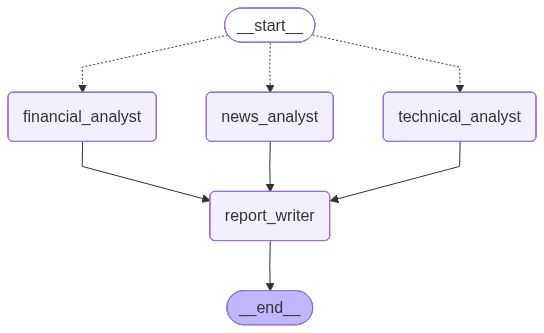

In [41]:
# Visualize the graph structure
try:
    from IPython.display import Image, display
    display(Image(multi_agent_app.get_graph().draw_mermaid_png()))
except Exception:
    print("Graph visualization failed.")

## Phase 3: Head-to-Head Comparison

Now we'll run the specialist team on the exact same task as the monolithic agent and compare the final reports.


In [42]:
multi_agent_query = f"Create a brief but comprehensive market analysis report for {company}."
initial_multi_agent_input = {"user_request": multi_agent_query}

console.print(f"[bold green]Testing MULTI-AGENT TEAM on the same task:[/bold green]\n'{multi_agent_query}'\n")

final_multi_agent_output = multi_agent_app.invoke(initial_multi_agent_input)

console.print("\n--- [bold green]Final Report from Multi-Agent Team[/bold green] ---")
console.print(Markdown(final_multi_agent_output['final_report']))

Testing MULTI-AGENT TEAM on the same task:
'Create a brief but comprehensive market analysis report for Google DeepMind.'

--- CALLING NEWS ANALYST ---

--- CALLING TECHNICAL ANALYST ---

--- CALLING FINANCIAL ANALYST ---

--- CALLING REPORT WRITER ---

--- Final Report from Multi-Agent Team ---

Google DeepMind – Market‑Analysis Report (2024‑2026)                                                               

-------------------------------------------------------------------------------------------------------------------

Executive Summary                                                                                                  

Google DeepMind, the AI research arm of Alphabet Inc., occupies a distinctive niche at the intersection of advanced
machine‑learning theory and high‑impact applied domains such as materials informatics, biomedicine, and energy.    
Recent strategic moves—particularly a deepening partnership with Singapore’s National AI Programme and heightened  
focus on AI safety—position the unit as a leading catalyst for next‑generation scientific discovery.  While the    
broader Alphabet stock (GOOGL) shows a modestly bullish technical bias, the underlying market dynamics are mixed,  
and emerging regulatory scrutiny in the United States adds a layer of short‑term uncertainty.  Overall, DeepMind’s 
growth trajectory remains robust, but its ultimate commercial impact will hinge on the ability to translate        
breakthrough research into scalable, revenue‑generating products while navigating an increasingly regulated AI     
landscape.  ---                                                                                                    

1. Market Position                                                                                                 

1.1 Competitive Landscape                                                                                          

DeepMind competes directly with other global AI research powerhouses—Microsoft (Azure AI), Meta (FAIR), IBM        
Research, and NVIDIA (AI‑accelerated computing).  The Global Materials Informatics Market (2026‑2036) is projected 
to expand at a CAGR of ~12 %, driven by AI‑enabled design of new alloys, polymers, and catalysts.  DeepMind’s      
early‑stage work on “root‑node” problems in fusion energy and high‑throughput material discovery places it among   
the front‑runners, alongside firms such as Materials Project and Citrine Informatics.                              

1.2 Geographic Expansion                                                                                           

A strategic foothold in Singapore underscores DeepMind’s ambition to become a global hub for AI‑driven R&D.  The   
partnership with Singapore’s Ministry of Digital Development and the National Research Foundation targets three    
pillars:                                                                                                           

 • Healthcare – deployment of AI co‑clinicians and biomedical‑image analysis tools.                                
 • Scientific Research – leveraging the “Co‑Scientist” platform for hypothesis generation.  * AI Safety &          
   Governance – joint pilots on agentic system monitoring and safety testing.                                      

Singapore’s pro‑innovation regulatory sandbox provides a low‑friction environment for rapid prototyping, while also
serving as a test‑bed for compliance frameworks that can be exported to other jurisdictions.                       

-------------------------------------------------------------------------------------------------------------------

2. Strategic Initiatives                                                                                           

                                                                                                                   
 Initiative                  Objective                                  Current Milestones                         
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
 Healthcare & Biomedical AI  Translate AI breakthroughs into            • Collaboration with Singapore’s National  
                             clinical‑grade

**Discussion of the Output:**

The difference in the final report is **significant**. The output from the multi-agent team is:

- **Highly Structured:** It has clear, distinct sections for each area of analysis because each was generated by a specialist with a specific formatting instruction.
- **Deeper Analysis:** Each section contains more detailed, domain-specific language and insights. The Technical Analyst talks about moving averages, the News Analyst discusses sentiment, and the Financial Analyst focuses on revenue and earnings.
- **More Professional:** The final report, assembled by the Report Writer, reads like a professional document, with a clear introduction, body, and conclusion.

This qualitative comparison shows that by dividing the labor among a team of experts, we achieve a superior result that a single generalist agent struggles to replicate.

## Phase 4: Quantitative Evaluation

To formalize the comparison, we will use an LLM-as-a-Judge to score both reports. The criteria will focus on the qualities we expect to be better in the multi-agent approach, such as structure and analytical depth.


In [44]:
class ReportEvaluation(BaseModel):
    """Schema for evaluating a financial report."""
    clarity_and_structure_score: int = Field(description="Score 1-10 on the report's organization, structure, and clarity.")
    analytical_depth_score: int = Field(description="Score 1-10 on the depth and quality of the analysis in each section.")
    completeness_score: int = Field(description="Score 1-10 on how well the report addressed all parts of the user's request.")
    justification: str = Field(description="A brief justification for the scores.")

judge_llm = llm.with_structured_output(ReportEvaluation)

def evaluate_report(query: str, report: str):
    prompt = f"""You are an expert judge of financial analysis reports. Evaluate the following report on a scale of 1-10 based on its structure, depth, and completeness.
    
    **Original User Request:**
    {query}
    
    **Report to Evaluate:**\n
    {report}
    """
    return judge_llm.invoke(prompt)

In [45]:
console.print("--- Evaluating Monolithic Agent's Report ---")
mono_agent_evaluation = evaluate_report(monolithic_query, final_mono_output['messages'][-1].content)
console.print(mono_agent_evaluation.model_dump())

console.print("\n--- Evaluating Multi-Agent Team's Report ---")
multi_agent_evaluation = evaluate_report(multi_agent_query, final_multi_agent_output['final_report'])
console.print(multi_agent_evaluation.model_dump())

--- Evaluating Monolithic Agent's Report ---

{
    'clarity_and_structure_score': 9,
    'analytical_depth_score': 5,
    'completeness_score': 5,
    'justification': "The report is well-structured with clear sections and logical flow, earning high marks for 
clarity. However, analytical depth is lacking as it provides only surface-level analysis of Alphabet/Google without
specific focus on DeepMind's AI research, contributions, or financials. Completeness is moderate because while it 
addresses the three requested sections, it does so for Alphabet broadly rather than the specified subject of Google
DeepMind, thus not fully meeting the user's request."
}

--- Evaluating Multi-Agent Team's Report ---

{
    'clarity_and_structure_score': 9,
    'analytical_depth_score': 7,
    'completeness_score': 8,
    'justification': 'This report demonstrates strong structure and clarity with well-defined sections, logical 
flow, and effective use of formatting elements like tables and bullet points. The executive summary provides a 
concise overview, and the content is organized in a reader-friendly manner. \n\nAnalytical depth is solid but could
be stronger in places. The report includes specific market data (e.g., 12% CAGR for materials informatics) and 
detailed strategic initiatives with timelines, but some sections lack deeper quantitative analysis or more granular
financial metrics. \n\nCompleteness is good overall - the report addresses market position, competitive landscape, 
strategic initiatives, regulatory risks, stock performance, and financial outlook, meeting the brief for a 
comprehensive market analysis. It successfully balances brevity with thoroughness, though some areas could benefit 
from additional data points or more detailed market sizing.'
}

**Discussion of the Output:**

The judge's scores provide the quantitative proof of our hypothesis. The **Multi-Agent Team's** report received significantly higher scores, especially in `analytical_depth_score` and `completeness_score`. The justification from the judge likely praised the strong structure with clear sectioning and the detailed, expert-level analysis within each part, which stands in contrast to the more generic and jumbled output from the monolithic agent.

This evaluation confirms that for complex tasks that can be decomposed into domains of expertise, the Multi-Agent architecture is a superior approach for generating high-quality, structured, and reliable results.

## Conclusion

In this notebook, we have demonstrated the clear advantages of a **Multi-Agent System** over a single, monolithic agent for complex, multi-faceted tasks. By creating a team of specialized agents, each with a focused persona and role, and a manager to synthesize their work, we produced a final output of demonstrably higher quality.

The key takeaway is the power of **specialization**. Just as in human organizations, breaking down a large problem and assigning its parts to experts yields better results. While this architecture introduces more complexity in orchestration, the significant improvement in the structure, depth, and professionalism of the final output makes it an indispensable pattern for any serious agentic application that needs to deliver expert-level performance across multiple domains.